In [1]:
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns
matplotlib.rcParams["figure.figsize"] = (10,6)

C:\Users\Admin\AppData\Local\Temp\ipykernel_1288\3652801007.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
df = pd.read_csv("heights (1).csv")
df.head()

,gender,height
0,Male,73.847017
1,Male,68.781904
2,Male,74.110105
3,Male,71.730978
4,Male,69.881796


In [5]:
df.sample(5)

,gender,height
9087,Female,60.457177
4950,Male,68.737221
9892,Female,61.143599
1367,Male,73.803025
4656,Male,70.602409


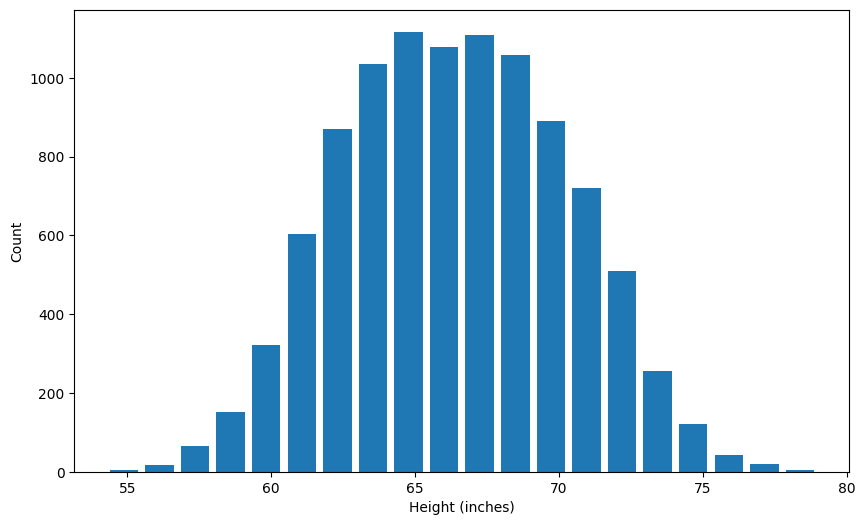

In [6]:
# Plot a histogram to see the distribution
plt.hist(df.height, bins=20, rwidth=0.8)
plt.xlabel("Height (inches)")
plt.ylabel("Count")
plt.show()

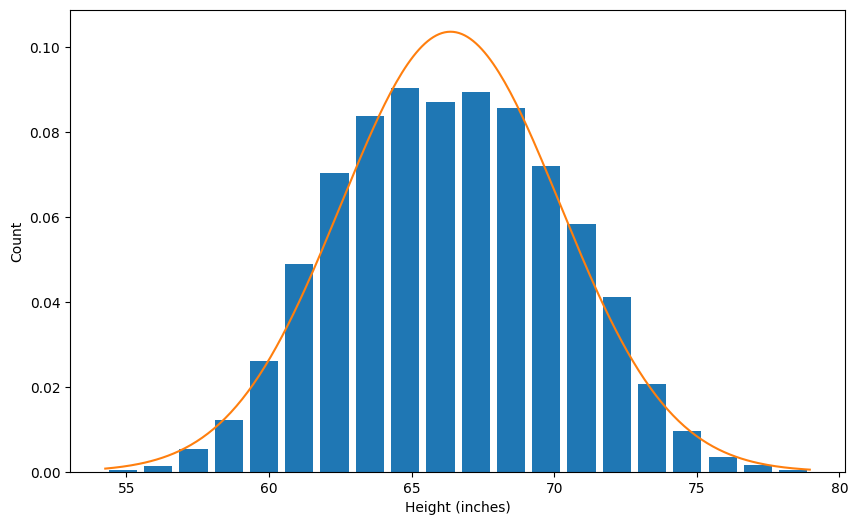

In [9]:
# Create a bell curv
from scipy.stats import norm
import numpy as np

plt.hist(df.height, bins=20, rwidth=0.8, density=True)
plt.xlabel("Height (inches)")
plt.ylabel("Count")

rng = np.arange(df.height.min(), df.height.max(), 0.1)
plt.plot(rng, norm.pdf(rng, df.height.mean(), df.height.std()))

In [10]:
df.height.mean()

66.367559754866

In [11]:
df.height.std()

3.847528120795573

In [12]:
upper_limit = df.height.mean() + 3*df.height.std()
upper_limit

77.91014411725271

In [14]:
lower_limit = df.height.mean() - 3 * df.height.std() 
lower_limit

54.824975392479274

In [15]:
df[(df.height>upper_limit) | (df.height<lower_limit)]

,gender,height
994,Male,78.095867
1317,Male,78.462053
2014,Male,78.998742
3285,Male,78.528210
3757,Male,78.621374
6624,Female,54.616858
9285,Female,54.263133


In [16]:
df1 = df[(df.height<upper_limit) & (df.height>lower_limit)]
df1.shape

(9993, 2)

In [17]:
df1.head()

,gender,height
0,Male,73.847017
1,Male,68.781904
2,Male,74.110105
3,Male,71.730978
4,Male,69.881796


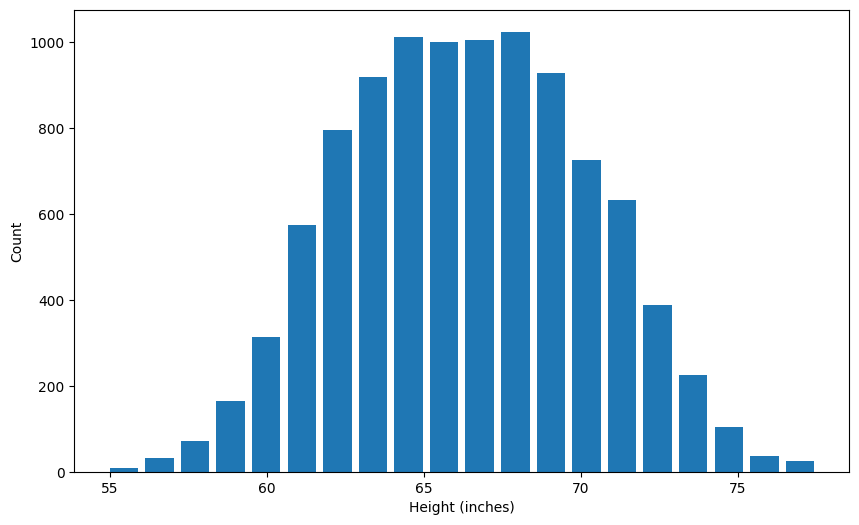

In [18]:
# Plot a histogram to see the distribution
plt.hist(df1.height, bins=20, rwidth=0.8)
plt.xlabel("Height (inches)")
plt.ylabel("Count")
plt.show()

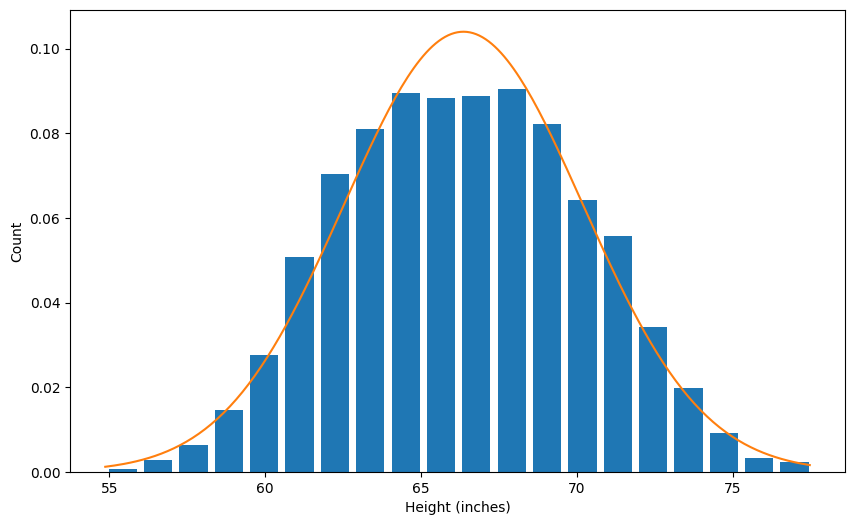

In [19]:
# Create a bell curv
from scipy.stats import norm
import numpy as np

plt.hist(df1.height, bins=20, rwidth=0.8, density=True)
plt.xlabel("Height (inches)")
plt.ylabel("Count")

rng = np.arange(df1.height.min(), df1.height.max(), 0.1)
plt.plot(rng, norm.pdf(rng, df1.height.mean(), df1.height.std()))

In [20]:
df.shape[0] - df1.shape[0]

7

In [21]:
# Use Z score to remove the data x - mean / std
df["zscore"] = (df.height - df.height.mean())/df.height.std()
df.head()

,gender,height,zscore
0,Male,73.847017,1.943964
1,Male,68.781904,0.627505
2,Male,74.110105,2.012343
3,Male,71.730978,1.393991
4,Male,69.881796,0.913375


In [24]:
# remove the data those are from -3 to 3 away
df[df.zscore>3]

,gender,height,zscore
994,Male,78.095867,3.048271
1317,Male,78.462053,3.143445
2014,Male,78.998742,3.282934
3285,Male,78.528210,3.160640
3757,Male,78.621374,3.184854


In [25]:
df2 = df[(df.zscore<3) & (df.zscore>-3)]
df2.shape

(9993, 3)

In [26]:
df.shape[0] - df2.shape[0]

7